In [56]:
import torch 
import numpy as np
import matplotlib.pyplot as plt

In [57]:
import torch.nn as nn
class PNN(torch.nn.Module):
    def __init__(self):
        super(PNN, self).__init__()
        self.lb = torch.tensor([-1.0, 0.0])
        self.ub = torch.tensor([1.0, 1.0])
       
        self.network=torch.nn.Sequential(
            nn.Linear(2,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,1)
        )

    def forward(self, x, t):
        input = torch.cat([x, t], dim=1)
        input = 2.0 * (input - self.lb) / (self.ub - self.lb) - 1.0
        return self.network(input)

In [58]:
model=PNN()

In [59]:


x = torch.tensor([[0.3]], dtype=torch.float32, requires_grad=True)

t = torch.tensor([[0.5]], dtype=torch.float32, requires_grad=True)

In [60]:
u=model(x, t)

In [61]:
u_x=torch.autograd.grad(
    outputs=u,
    inputs=x,
    grad_outputs=torch.ones_like(u),    
    create_graph=True,
)[0]

In [62]:
u_t=torch.autograd.grad(
    outputs=u,
    inputs=t,
    grad_outputs=torch.ones_like(u),
    create_graph=True,
)[0]

In [63]:
u_xx=torch.autograd.grad(
    outputs=u_x,
    inputs=x,
    grad_outputs=torch.ones_like(u_x),
    create_graph=True,
)[0]

In [64]:
nu=0.01/torch.pi
f = u_t + u*u_x - nu*u_xx

In [65]:
physics_loss=torch.mean(f**2)

In [66]:
N_ic=100
x_ic=-1+2*torch.rand(N_ic,1)
t_ic=torch.zeros(x_ic.shape)
u_ic=-torch.sin(torch.pi*x_ic)

In [67]:
N_bc=100
t_bc=torch.rand(N_bc,1)
x_left=-torch.ones(t_bc.shape)
x_right=torch.ones(t_bc.shape)
u_left = torch.zeros_like(t_bc)
u_right = torch.zeros_like(t_bc)

In [68]:
N_f = 10000

x_f = -1 + 2*torch.rand(N_f,1)

t_f = torch.rand(N_f,1)

In [69]:
def physics_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]
    
    nu = 0.01 / torch.pi
    f = u_t + u * u_x - nu * u_xx
    return f

In [70]:
model = PNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [78]:
epochs=5000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    u_ic_pred = model(x_ic, t_ic)
    ic_loss = torch.mean((u_ic_pred - u_ic)**2)
    u_left_pred = model(x_left, t_bc)
    u_right_pred = model(x_right, t_bc)
    bc_loss = torch.mean((u_left_pred)**2) + torch.mean((u_right_pred )**2)
    
    # Compute physics loss
    f = physics_residual(model, x_f, t_f)
    physics_loss = torch.mean(f**2)
    
    # Compute initial condition loss
    
    
    
    # Compute boundary condition loss
  
    # Total loss
    total_loss = physics_loss + ic_loss + bc_loss
    
    total_loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {total_loss.item()}')
        print(
                f"Epoch {epoch:5d} | "
                f"Total={total_loss.item():.6f} | "
                f"IC={ic_loss.item():.6f} | "
                f"BC={bc_loss.item():.6f} | "
                f"PDE={physics_loss.item():.6f}")


Epoch 0, Loss: 0.0013147350400686264
Epoch     0 | Total=0.001315 | IC=0.000384 | BC=0.000004 | PDE=0.000927
Epoch 100, Loss: 0.0012937957653775811
Epoch   100 | Total=0.001294 | IC=0.000375 | BC=0.000004 | PDE=0.000915
Epoch 200, Loss: 0.0012847536709159613
Epoch   200 | Total=0.001285 | IC=0.000375 | BC=0.000004 | PDE=0.000905
Epoch 300, Loss: 0.001259816694073379
Epoch   300 | Total=0.001260 | IC=0.000366 | BC=0.000004 | PDE=0.000889
Epoch 400, Loss: 0.0025926893576979637
Epoch   400 | Total=0.002593 | IC=0.000388 | BC=0.000012 | PDE=0.002192
Epoch 500, Loss: 0.001228147535584867
Epoch   500 | Total=0.001228 | IC=0.000359 | BC=0.000004 | PDE=0.000866
Epoch 600, Loss: 0.001211206428706646
Epoch   600 | Total=0.001211 | IC=0.000352 | BC=0.000004 | PDE=0.000856
Epoch 700, Loss: 0.0012093251571059227
Epoch   700 | Total=0.001209 | IC=0.000366 | BC=0.000003 | PDE=0.000840
Epoch 800, Loss: 0.0011833910830318928
Epoch   800 | Total=0.001183 | IC=0.000346 | BC=0.000003 | PDE=0.000834
Epoch 

In [79]:
x = torch.linspace(-1, 1, 200)
t = torch.linspace(0, 1, 100)

In [80]:
X, T = torch.meshgrid(x, t, indexing="ij")

In [81]:
x_test = X.reshape(-1,1)

t_test = T.reshape(-1,1)

In [82]:
with torch.no_grad():
    u_pred = model(x_test, t_test)
    u=u_pred.reshape(X.shape)

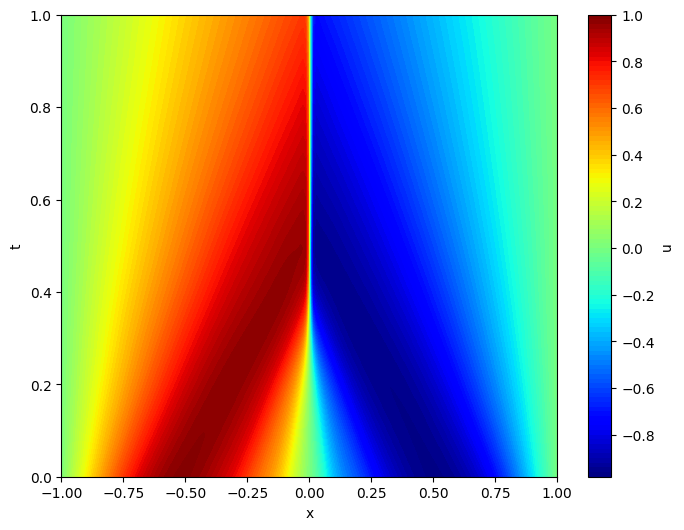

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.contourf(
    X.numpy(),
    T.numpy(),
    u.numpy(),
    levels=100,
    cmap="jet"
)

plt.colorbar(label="u")

plt.xlabel("x")
plt.ylabel("t")

plt.show()